Name: Kushagra Raghuvanshi

Registration Number: 23BSA10072

Application Number: IN26011064

Batch Number: 2B

# CartPole-v1: Q-Learning, DQN, PPO, A2C, and Discrete SAC

This notebook trains and evaluates five RL algorithms on `CartPole-v1` from Gymnasium:

1. **Q-Learning** — tabular, from scratch (discretized state space)
2. **DQN** — via Stable-Baselines3
3. **PPO** — via Stable-Baselines3
4. **A2C** — via Stable-Baselines3
5. **SAC (discrete adaptation)** — from scratch in PyTorch

In [ ]:
!pip install -q gymnasium stable-baselines3[extra] torch matplotlib numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 8.5 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from collections import deque
import random

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

results = {}  # {algo_name: {'train_rewards': [...], 'eval_mean': x, 'eval_std': x}}


In [ ]:
def evaluate_policy_custom(action_fn, env_name="CartPole-v1", n_episodes=20, seed=1000):
    """Runs greedy rollouts and returns (mean, std) of episode return."""
    env = gym.make(env_name)
    scores = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done = False
        total = 0
        while not done:
            action = action_fn(obs)
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total += reward
        scores.append(total)
    env.close()
    return float(np.mean(scores)), float(np.std(scores))


def moving_average(data, window=50):
    data = np.asarray(data, dtype=float)
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window) / window, mode="valid")


## 1. Q-Learning (tabular, from scratch)

CartPole's state is continuous (`[cart position, cart velocity, pole angle, pole angular velocity]`), so we discretize it into bins to build a Q-table. Epsilon-greedy exploration decays over training.

In [ ]:
class QLearningAgent:
    def __init__(self, env, bins=(6, 12, 6, 12), alpha=0.1, gamma=0.99,
                 eps_start=1.0, eps_end=0.05, eps_decay=0.9995):
        self.env = env
        self.bins = bins
        self.alpha = alpha
        self.gamma = gamma
        self.eps = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay

        # Reasonable bounds for CartPole-v1 (velocity/angular velocity are technically
        # unbounded, so we clip to a practical range that covers almost all episodes).
        self.obs_low = np.array([-2.4, -3.0, -0.28, -3.5])
        self.obs_high = np.array([2.4, 3.0, 0.28, 3.5])

        self.q_table = np.zeros(bins + (env.action_space.n,))

    def discretize(self, obs):
        obs = np.clip(obs, self.obs_low, self.obs_high)
        ratios = (obs - self.obs_low) / (self.obs_high - self.obs_low)
        idx = (ratios * np.array(self.bins)).astype(int)
        idx = np.clip(idx, 0, np.array(self.bins) - 1)
        return tuple(idx)

    def act(self, obs, greedy=False):
        state = self.discretize(obs)
        if not greedy and np.random.rand() < self.eps:
            return self.env.action_space.sample()
        return int(np.argmax(self.q_table[state]))

    def update(self, obs, action, reward, next_obs, done):
        s = self.discretize(obs)
        s2 = self.discretize(next_obs)
        best_next = np.max(self.q_table[s2])
        td_target = reward + self.gamma * best_next * (1 - done)
        self.q_table[s + (action,)] += self.alpha * (td_target - self.q_table[s + (action,)])

    def decay_epsilon(self):
        self.eps = max(self.eps_end, self.eps * self.eps_decay)


def train_qlearning(n_episodes=3000):
    env = gym.make("CartPole-v1")
    agent = QLearningAgent(env)
    episode_rewards = []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=SEED + ep)
        done = False
        total_reward = 0
        while not done:
            action = agent.act(obs)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            agent.update(obs, action, reward, next_obs, done)
            obs = next_obs
            total_reward += reward
        agent.decay_epsilon()
        episode_rewards.append(total_reward)
        if (ep + 1) % 500 == 0:
            print(f"[Q-Learning] Episode {ep+1}, avg reward (last 100): "
                  f"{np.mean(episode_rewards[-100:]):.1f}, eps={agent.eps:.3f}")

    env.close()
    return agent, episode_rewards


q_agent, q_rewards = train_qlearning(n_episodes=3000)


[Q-Learning] Episode 500, avg reward (last 100): 28.5, eps=0.779
[Q-Learning] Episode 1000, avg reward (last 100): 51.6, eps=0.606
[Q-Learning] Episode 1500, avg reward (last 100): 80.7, eps=0.472
[Q-Learning] Episode 2000, avg reward (last 100): 103.6, eps=0.368
[Q-Learning] Episode 2500, avg reward (last 100): 117.0, eps=0.286
[Q-Learning] Episode 3000, avg reward (last 100): 124.1, eps=0.223


In [ ]:
def q_action_fn(obs):
    return q_agent.act(obs, greedy=True)

mean_r, std_r = evaluate_policy_custom(q_action_fn)
print(f"Q-Learning evaluation: {mean_r:.1f} +/- {std_r:.1f}")
results["Q-Learning"] = {"train_rewards": q_rewards, "eval_mean": mean_r, "eval_std": std_r}


Q-Learning evaluation: 171.9 +/- 83.5


## 2-4. DQN, PPO, A2C (Stable-Baselines3)

All three natively support discrete action spaces, so we can use SB3's implementations directly. We use `Monitor` to log per-episode returns during training for the comparison plot later.

In [ ]:
from stable_baselines3 import DQN, PPO, A2C
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor


def train_sb3(algo_class, algo_name, total_timesteps=50000, policy="MlpPolicy", **kwargs):
    env = Monitor(gym.make("CartPole-v1"))
    model = algo_class(policy, env, verbose=0, seed=SEED, **kwargs)
    model.learn(total_timesteps=total_timesteps)

    mean_r, std_r = evaluate_policy(model, env, n_eval_episodes=20)
    print(f"[{algo_name}] Evaluation: {mean_r:.1f} +/- {std_r:.1f}")

    ep_rewards = env.get_episode_rewards()
    env.close()
    return model, ep_rewards, mean_r, std_r


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
dqn_model, dqn_rewards, dqn_mean, dqn_std = train_sb3(
    DQN, "DQN", total_timesteps=50000,
    learning_rate=1e-3, buffer_size=50000, exploration_fraction=0.2,
)
results["DQN"] = {"train_rewards": dqn_rewards, "eval_mean": dqn_mean, "eval_std": dqn_std}


[DQN] Evaluation: 37.8 +/- 21.5


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
ppo_model, ppo_rewards, ppo_mean, ppo_std = train_sb3(
    PPO, "PPO", total_timesteps=50000, learning_rate=3e-4,
)
results["PPO"] = {"train_rewards": ppo_rewards, "eval_mean": ppo_mean, "eval_std": ppo_std}


[PPO] Evaluation: 500.0 +/- 0.0


In [ ]:
a2c_model, a2c_rewards, a2c_mean, a2c_std = train_sb3(
    A2C, "A2C", total_timesteps=50000, learning_rate=7e-4,
)
results["A2C"] = {"train_rewards": a2c_rewards, "eval_mean": a2c_mean, "eval_std": a2c_std}


[A2C] Evaluation: 500.0 +/- 0.0


## 5. SAC — Discrete Adaptation (from scratch)

As noted above, SAC assumes a continuous action space (its policy outputs a mean/std for a Gaussian and uses the reparameterization trick). CartPole needs a categorical policy instead. This implementation follows Christodoulou (2019):

- The actor outputs action **probabilities** directly (softmax), so entropy and log-probs are computed exactly — no reparameterization needed.
- Two Q-networks (`Q1`, `Q2`) estimate `Q(s, a)` for every discrete action, with target networks updated via Polyak averaging.
- The temperature `alpha` is learned automatically to hit a target entropy.

In [ ]:
class DiscreteActor(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        logits = self.net(x)
        probs = F.softmax(logits, dim=-1)
        log_probs = F.log_softmax(logits, dim=-1)
        return probs, log_probs


class QNetwork(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(args)

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        obs, act, rew, next_obs, done = zip(*batch)
        return (torch.FloatTensor(np.array(obs)),
                torch.LongTensor(act),
                torch.FloatTensor(rew),
                torch.FloatTensor(np.array(next_obs)),
                torch.FloatTensor(done))

    def __len__(self):
        return len(self.buffer)


In [ ]:
def train_discrete_sac(n_episodes=400, gamma=0.99, tau=0.005, lr=3e-4,
                        batch_size=64, target_entropy_ratio=0.9):
    env = gym.make("CartPole-v1")
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    actor = DiscreteActor(obs_dim, n_actions)
    q1, q2 = QNetwork(obs_dim, n_actions), QNetwork(obs_dim, n_actions)
    q1_target, q2_target = QNetwork(obs_dim, n_actions), QNetwork(obs_dim, n_actions)
    q1_target.load_state_dict(q1.state_dict())
    q2_target.load_state_dict(q2.state_dict())

    actor_opt = torch.optim.Adam(actor.parameters(), lr=lr)
    q1_opt = torch.optim.Adam(q1.parameters(), lr=lr)
    q2_opt = torch.optim.Adam(q2.parameters(), lr=lr)

    log_alpha = torch.zeros(1, requires_grad=True)
    alpha_opt = torch.optim.Adam([log_alpha], lr=lr)
    target_entropy = target_entropy_ratio * np.log(n_actions)

    buffer = ReplayBuffer()
    episode_rewards = []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=SEED + ep)
        done = False
        total_reward = 0

        while not done:
            with torch.no_grad():
                probs, _ = actor(torch.FloatTensor(obs).unsqueeze(0))
                action = torch.multinomial(probs, 1).item()

            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            buffer.push(obs, action, reward, next_obs, float(done))
            obs = next_obs
            total_reward += reward

            if len(buffer) >= batch_size:
                b_obs, b_act, b_rew, b_next_obs, b_done = buffer.sample(batch_size)
                alpha = log_alpha.exp()

                # --- Critic update ---
                with torch.no_grad():
                    next_probs, next_log_probs = actor(b_next_obs)
                    min_q_next = torch.min(q1_target(b_next_obs), q2_target(b_next_obs))
                    v_next = (next_probs * (min_q_next - alpha * next_log_probs)).sum(-1)
                    target_q = b_rew + gamma * (1 - b_done) * v_next

                q1_vals = q1(b_obs).gather(1, b_act.unsqueeze(-1)).squeeze(-1)
                q2_vals = q2(b_obs).gather(1, b_act.unsqueeze(-1)).squeeze(-1)
                q1_loss = F.mse_loss(q1_vals, target_q)
                q2_loss = F.mse_loss(q2_vals, target_q)

                q1_opt.zero_grad(); q1_loss.backward(); q1_opt.step()
                q2_opt.zero_grad(); q2_loss.backward(); q2_opt.step()

                # --- Actor update ---
                probs, log_probs = actor(b_obs)
                with torch.no_grad():
                    min_q = torch.min(q1(b_obs), q2(b_obs))
                actor_loss = (probs * (alpha.detach() * log_probs - min_q)).sum(-1).mean()
                actor_opt.zero_grad(); actor_loss.backward(); actor_opt.step()

                # --- Temperature update ---
                entropy = -(probs * log_probs).sum(-1)
                alpha_loss = -(log_alpha * (target_entropy - entropy.detach())).mean()
                alpha_opt.zero_grad(); alpha_loss.backward(); alpha_opt.step()

                # --- Target network Polyak update ---
                for tp, p in zip(q1_target.parameters(), q1.parameters()):
                    tp.data.copy_(tau * p.data + (1 - tau) * tp.data)
                for tp, p in zip(q2_target.parameters(), q2.parameters()):
                    tp.data.copy_(tau * p.data + (1 - tau) * tp.data)

        episode_rewards.append(total_reward)
        if (ep + 1) % 50 == 0:
            print(f"[Discrete SAC] Episode {ep+1}, avg reward (last 50): "
                  f"{np.mean(episode_rewards[-50:]):.1f}")

    env.close()
    return actor, episode_rewards


sac_actor, sac_rewards = train_discrete_sac(n_episodes=400)


[Discrete SAC] Episode 50, avg reward (last 50): 20.2
[Discrete SAC] Episode 100, avg reward (last 50): 102.2
[Discrete SAC] Episode 150, avg reward (last 50): 221.8
[Discrete SAC] Episode 200, avg reward (last 50): 170.5
[Discrete SAC] Episode 250, avg reward (last 50): 171.1
[Discrete SAC] Episode 300, avg reward (last 50): 204.2
[Discrete SAC] Episode 350, avg reward (last 50): 143.5
[Discrete SAC] Episode 400, avg reward (last 50): 170.1


In [ ]:
def sac_action_fn(obs):
    with torch.no_grad():
        probs, _ = sac_actor(torch.FloatTensor(obs).unsqueeze(0))
        return torch.argmax(probs, dim=-1).item()

sac_mean, sac_std = evaluate_policy_custom(sac_action_fn)
print(f"Discrete SAC evaluation: {sac_mean:.1f} +/- {sac_std:.1f}")
results["SAC (discrete)"] = {"train_rewards": sac_rewards, "eval_mean": sac_mean, "eval_std": sac_std}


Discrete SAC evaluation: 499.6 +/- 1.5


## 6. Comparison

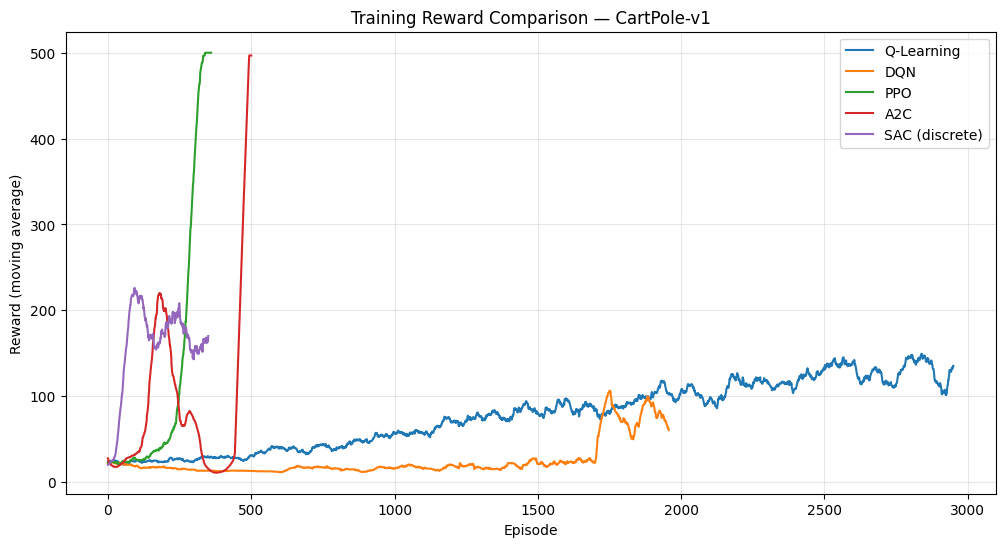

In [ ]:
plt.figure(figsize=(12, 6))
for name, res in results.items():
    window = max(1, min(50, len(res["train_rewards"]) // 5 or 1))
    smoothed = moving_average(res["train_rewards"], window=window)
    plt.plot(smoothed, label=name)
plt.xlabel("Episode")
plt.ylabel("Reward (moving average)")
plt.title("Training Reward Comparison — CartPole-v1")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("training_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


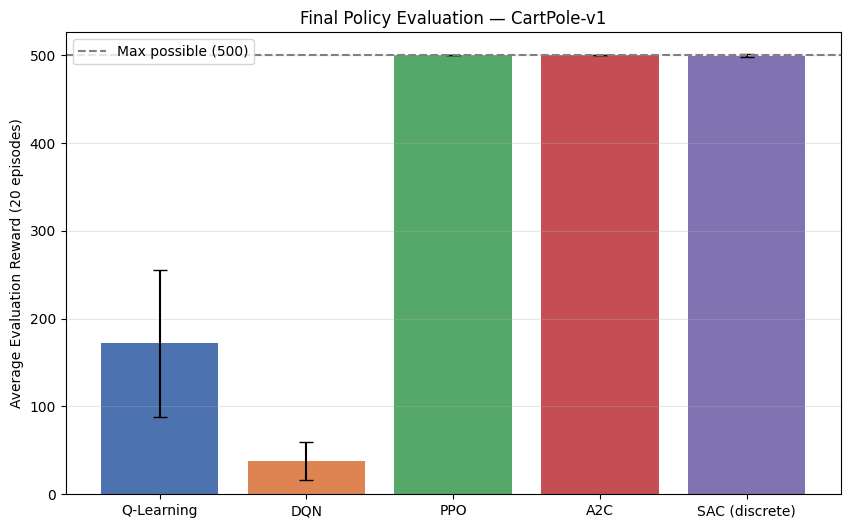


=== Summary ===
Q-Learning: 171.9 +/- 83.5
DQN: 37.8 +/- 21.5
PPO: 500.0 +/- 0.0
A2C: 500.0 +/- 0.0
SAC (discrete): 499.6 +/- 1.5


In [ ]:
names = list(results.keys())
means = [results[n]["eval_mean"] for n in names]
stds = [results[n]["eval_std"] for n in names]

plt.figure(figsize=(10, 6))
plt.bar(names, means, yerr=stds, capsize=5,
        color=["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"])
plt.ylabel("Average Evaluation Reward (20 episodes)")
plt.title("Final Policy Evaluation — CartPole-v1")
plt.axhline(y=500, color="gray", linestyle="--", label="Max possible (500)")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.savefig("evaluation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Summary ===")
for name in names:
    m = results[name]["eval_mean"]
    s = results[name]["eval_std"]
    print(f"{name}: {m:.1f} +/- {s:.1f}")
